# **Image captioning - Report**

## Loss Curves


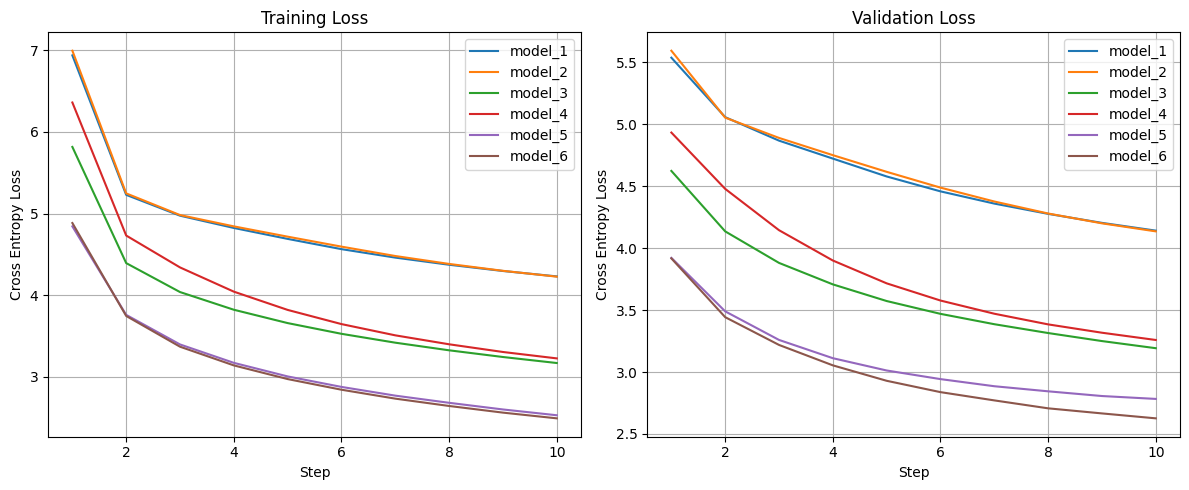

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSVs (update paths if needed)
train_df = pd.read_csv("report_utils/train_loss_curves.csv")
val_df = pd.read_csv("report_utils/val_loss_curves.csv")

# Define model names and colors
models = ['model_1', 'model_2', 'model_3', 'model_4', 'model_5', 'model_6']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Create subplots
plt.figure(figsize=(12, 5))

# Plot training loss
plt.subplot(1, 2, 1)
for model, color in zip(models, colors):
    col_name = f"{model} - train/cross_entropy_loss"
    if col_name in train_df.columns:
        plt.plot(train_df["Step"], train_df[col_name], label=model, color=color)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True)

# Plot validation loss
plt.subplot(1, 2, 2)
for model, color in zip(models, colors):
    col_name = f"{model} - val/cross_entropy_loss"
    if col_name in val_df.columns:
        plt.plot(val_df["Step"], val_df[col_name], label=model, color=color)
plt.title("Validation Loss")
plt.xlabel("Step")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True)

# Final layout and show
plt.tight_layout()
plt.show()

### **Training Curves**
- All models show a steady decrease in training loss.
- Model 1 (baseline) converges the slowest, showing the highest loss across epochs.
- Model 2 and 3 improve significantly due to the use of DINOv2 and GRU.
- Model 5 and 6 have the lowest training loss, highlighting the efficiency of transformer-based decoders.

### **Validation Curves**
- Model 1 overfits quickly and struggles to generalize.
- Model 2 benefits from the strong visual features of DINOv2 but plateaus early.
- Model 3 and 4 are more stable and achieve lower validation loss than previous models.
- Model 5 (Transformer with global image token) performs well but doesn't reduce validation loss much further than GRU models.
- Model 6 achieves the lowest validation loss, showing the advantage of attending to spatial image features.

## BLEU Scores

| Model    | BLEU-1 | BLEU-2 | BLEU-3 | BLEU-4 |
|----------|--------|--------|--------|--------|
| Model 1  | 0.4215 | 0.2137 | 0.1112 | 0.0645 |
| Model 2  | 0.5345 | 0.3100 | 0.1610 | 0.0890 |
| Model 3  | 0.5787 | 0.3925 | 0.2540 | 0.1662 |
| Model 4  | 0.6004 | 0.4236 | 0.2813 | 0.1861 |
| Model 5  | 0.6230 | 0.4498 | 0.3119 | 0.2119 |
| Model 6  | 0.6711 | 0.5094 | 0.3756 | 0.2720 |

There is a clear upward trend in BLEU scores from Model 1 through Model 6, which aligns well with the improvements observed in the validation loss curves.

**Models analysis**:
- Model 1 initial loss is high until it becomes unstable.        
- Model 2 loss is similar to Model 1, but has a big jump in BLEU-1/2     
- Model 3 Smoother loss and Big jump in BLEU-3/4 
- Model 4 has further BLEU gains
- Model 5 has train loss improvement, however BLEU barely improves
- Model 6 loss similar to Model 5, but all BLEU scores raise

BLEU scores correlate well with validation loss, especially BLEU-3 and BLEU-4, which reflect the model’s ability to generate longer coherent sequences.

## Model 4

In Model 3, the image encoding from DINOv2 was used as the first input token to the decoder. This forced the decoder to interpret both image and text tokens in the same sequence, making learning harder.

In Model 4, instead of injecting the image encoding as an input token, we use it to initialize the hidden state of the decoder GRU, while keeping the input sequence purely textual. This separates the visual context from language modeling and simplifies the decoding process.

The <CLS> token was projected to match the GRU's hidden dimension, and used it to initialize all decoder layers. This approach led to more stable training and slightly improved BLEU scores compared to Model 3.

While effective, this method still relies on a single global image vector, which limits its ability to capture detailed spatial information.

## Model 5

In Model 5, the RNN decoder was replaced with a Transformer decoder to take advantage of its parallelism and long-range modeling capabilities. To condition the Transformer on the image, the projected <CLS> token was prepended from the DINOv2 encoder to the beginning of the token sequence. This token was treated as the visual context token, and the Transformer was trained to attend to it throughout the caption generation process using causal self-attention.

The key difference between Transformers and RNNs lies in how they handle sequences:
- RNNs process tokens sequentially, which limits their ability to capture long-range dependencies efficiently.
- Transformers process all tokens in parallel, attending to any previous position directly through self-attention.
- This allows better modeling of global dependencies, which is especially useful for coherent and fluent sentence generation.

In my experiments, Model 5 showed better training efficiency and more stable learning than Model 4. However, the BLEU score improvement was modest. This is likely because the model still relies on a single global image token (<CLS>), limiting its ability to capture detailed visual information